###Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import BertTokenizer

###Load Dataset

In [2]:
data = pd.read_csv('Tweets.csv')

print(data.shape)
data.head()

(27481, 4)


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


###Check Columns

In [3]:
print(data.columns)

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


###Preprocessing

In [4]:
texts = data['text'].fillna('').astype(str).values
labels = LabelEncoder().fit_transform(data['sentiment'])

print("Sample text:", texts[0])
print("Encoded label:", labels[0])

Sample text:  I`d have responded, if I were going
Encoded label: 1


###Train-Test Split

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

###Tokenization

In [6]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

max_len = 50

X_train = tokenizer(
    list(X_train_text),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='np'
)['input_ids']

X_test = tokenizer(
    list(X_test_text),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_tensors='np'
)['input_ids']

print("X_train shape:", X_train.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


X_train shape: (21984, 50)


###Build Models

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

vocab_size = int(max(X_train.max(), X_test.max())) + 1

def build_rnn():
    return Sequential([
        Embedding(vocab_size, 128, input_length=max_len),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])

def build_lstm():
    return Sequential([
        Embedding(vocab_size, 128, input_length=max_len),
        LSTM(128),
        Dense(3, activation='softmax')
    ])

def build_gru():
    return Sequential([
        Embedding(vocab_size, 128, input_length=max_len),
        GRU(128),
        Dense(3, activation='softmax')
    ])

###Train Models

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
import time

models = {
    'RNN': build_rnn(),
    'LSTM': build_lstm(),
    'GRU': build_gru()
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        validation_data=(X_test, y_test),
        callbacks=[es],
        verbose=1
    )

    end = time.time()

    results[name] = {
        'history': history,
        'time': end - start
    }


Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.3783 - loss: 1.1070 - val_accuracy: 0.4008 - val_loss: 1.0948
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.3741 - loss: 1.1063 - val_accuracy: 0.4066 - val_loss: 1.0990
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 40s 58ms/step - accuracy: 0.3901 - loss: 1.0939 - val_accuracy: 0.4062 - val_loss: 1.0892
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.3957 - loss: 1.0929 - val_accuracy: 0.4062 - val_loss: 1.1024
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.3928 - loss: 1.0934 - val_accuracy: 0.4062 - val_loss: 1.0964

Training LSTM...
Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.4027 - loss: 1.0876 - val_accuracy: 0.3087 - val_loss: 1.0934
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 89s 129ms/step - accuracy: 0.4314 - loss: 1.0674 - val_accuracy: 0.4608 - val_loss: 1.0431
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 140s 126ms/step - accuracy: 0.

###Plot Accuracy

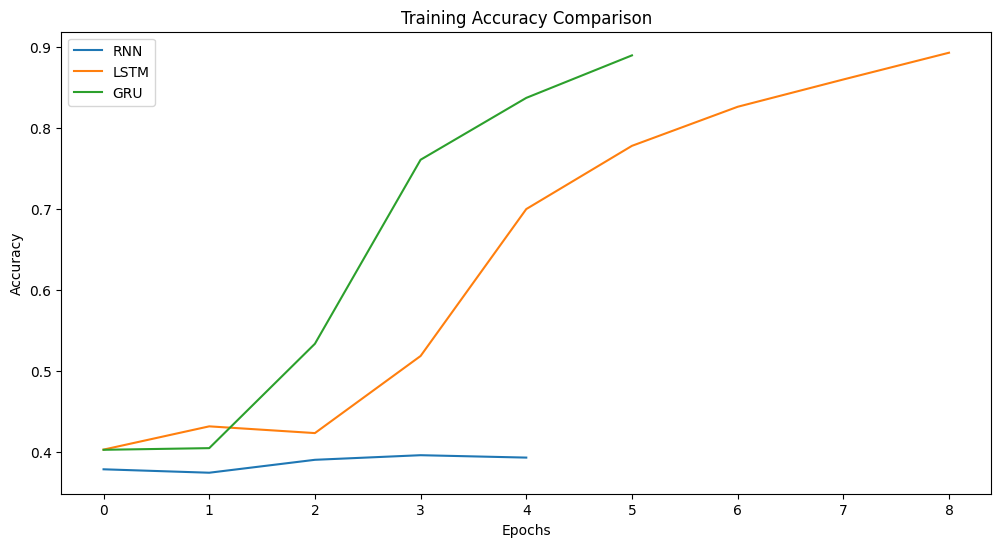

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for name, result in results.items():
    plt.plot(result['history'].history['accuracy'], label=name)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

###Plot Loss

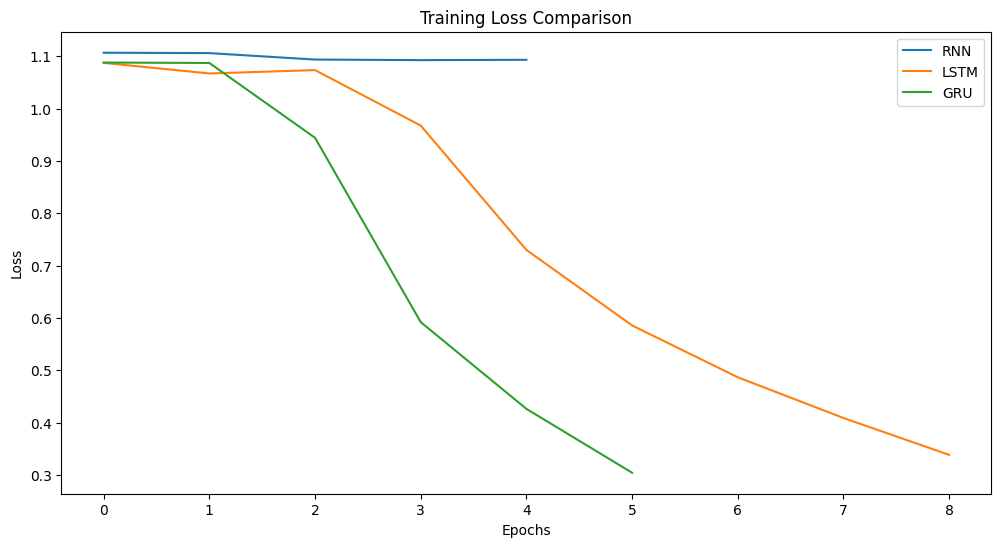

In [10]:
plt.figure(figsize=(12, 6))

for name, result in results.items():
    plt.plot(result['history'].history['loss'], label=name)

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

###Training Time Comparison

In [11]:
for name, result in results.items():
    print(f"{name} Training Time: {result['time']:.2f} seconds")

RNN Training Time: 213.41 seconds
LSTM Training Time: 891.39 seconds
GRU Training Time: 461.16 seconds


###Sequence Length Experiment

In [12]:
sequence_lengths = [10, 20, 40, 60, 80]

rnn_acc, lstm_acc, gru_acc = [], [], []

for l in sequence_lengths:
    print(f"\nTesting sequence length: {l}")

    X_train_l = tokenizer(
        list(X_train_text),
        padding='max_length',
        truncation=True,
        max_length=l,
        return_tensors='np'
    )['input_ids']

    X_test_l = tokenizer(
        list(X_test_text),
        padding='max_length',
        truncation=True,
        max_length=l,
        return_tensors='np'
    )['input_ids']

    vocab_size_l = int(max(X_train_l.max(), X_test_l.max())) + 1

    models = {
        'RNN': Sequential([
            Embedding(vocab_size_l, 128),
            SimpleRNN(128),
            Dense(3, activation='softmax')
        ]),
        'LSTM': Sequential([
            Embedding(vocab_size_l, 128),
            LSTM(128),
            Dense(3, activation='softmax')
        ]),
        'GRU': Sequential([
            Embedding(vocab_size_l, 128),
            GRU(128),
            Dense(3, activation='softmax')
        ])
    }

    for name, model in models.items():
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_train_l,
            y_train,
            epochs=3,
            batch_size=64,
            validation_data=(X_test_l, y_test),
            verbose=0
        )

        _, acc = model.evaluate(X_test_l, y_test, verbose=0)

        if name == 'RNN':
            rnn_acc.append(acc)
        elif name == 'LSTM':
            lstm_acc.append(acc)
        else:
            gru_acc.append(acc)

print("\nRNN:", rnn_acc)
print("LSTM:", lstm_acc)
print("GRU:", gru_acc)


Testing sequence length: 10

Testing sequence length: 20

Testing sequence length: 40

Testing sequence length: 60

Testing sequence length: 80

RNN: [0.553756594657898, 0.6145170331001282, 0.4122248589992523, 0.40567582845687866, 0.40603965520858765]
LSTM: [0.588138997554779, 0.6599963903427124, 0.7118428349494934, 0.40549391508102417, 0.40567582845687866]
GRU: [0.5797708034515381, 0.6680006980895996, 0.7254866361618042, 0.40567582845687866, 0.40567582845687866]
